In [3]:
# https://github.com/ThisIsJorgeLima/movielens/blob/master/SVD_Model.ipynb
# algorithm
# !~/.conda/envs/content_rating/bin/pip install -U scikit-learn
# from sklearn.neighbors import NearestNeighbors

# sparse matrix
# from scipy.sparse import csr_matrix

# string matching
# !~/.conda/envs/content_rating/bin/pip install fuzzywuzzy
# !~/.conda/envs/content_rating/bin/pip install python-Levenshtein
# ! pip install scikit-learn
# ! pip install fuzzywuzzy
# ! pip install python-Levenshtein
# ! pip install sparse==0.1.1

#classics
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
data_path = "/home/hhyamamura/workspace/contentRecommendation/ml-25m/"
movies_filename = 'movies.csv'
ratings_filename = 'ratings.csv'

#read data

movies = pd.read_csv(
    os.path.join(data_path, movies_filename),
    usecols=['movieId', 'title', 'genres'],
    dtype={'movieId': 'int32', 'title': 'str'})

ratings = pd.read_csv(
    os.path.join(data_path, ratings_filename),
    usecols=['userId', 'movieId', 'rating', 'timestamp'],
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

# Rename the columns to match the required format
movies.rename(columns={'movieId': 'movie_id', 'title': 'title', 'genres': 'genres'}, inplace=True)
ratings.rename(columns={'userId': 'user_id', 'movieId': 'movie_id', 'rating': 'rating', 'timestamp': 'timestamp'}, inplace=True)

In [5]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

In [6]:
# Extract the 'qtyRatings' column
data = ratings_per_user_sorted['qtyRatings']

# Calculate the quartiles and interquartile range (IQR)
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Calculate the median
median = np.median(data)

# Calculate the minimum and maximum values
minimum = np.min(data)
maximum = np.max(data)

# Calculate the lower and upper bounds for outliers
k = 2.5 # When k = 1.5 Tukey’s Fences becomes IQR
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

# Identify the outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

# Print the statistics
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")
print(f"Median: {median}")
print(f"1st Quartile (Q1): {Q1}")
print(f"3rd Quartile (Q3): {Q3}")
print(f"Interquartile Range (IQR): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

# Identify outliers
df_user_outliers = ratings_per_user_sorted[(ratings_per_user_sorted['qtyRatings'] < lower_bound) |
                                            (ratings_per_user_sorted['qtyRatings'] > upper_bound)
                                            ]

# Print out the userIds that are outliers
print("Outlier userIds (sorted by qty ratings):\n", df_user_outliers.sort_values(by='qtyRatings'))

Minimum: 20
Maximum: 32202
Median: 71.0
1st Quartile (Q1): 36.0
3rd Quartile (Q3): 162.0
Interquartile Range (IQR): 126.0
Lower Bound for Outliers: -279.0
Upper Bound for Outliers: 477.0
Outlier userIds (sorted by qty ratings):
         user_id  qtyRatings
11232     11233         478
52511     52512         478
88407     88408         478
56080     56081         478
81220     81221         478
...         ...         ...
20054     20055        7488
33843     33844        7919
137292   137293        8913
80973     80974        9178
72314     72315       32202

[10413 rows x 2 columns]


In [7]:
# remove all df_user_outliers
ratings = ratings[~ratings['user_id'].isin(df_user_outliers['user_id'])]

In [8]:
# Get unique users
unique_users = ratings['user_id'].unique()

# Seed for reproducibility
SEED = 42

# Split users into train (70%), test (15%), and validation (15%)
training_ratio=0.7
train_users, temp_users = train_test_split(unique_users, test_size=(1-training_ratio), random_state=SEED)
test_users, val_users = train_test_split(temp_users, test_size=0.5, random_state=SEED)

# Create masks to filter the dataframes
train_mask = ratings['user_id'].isin(train_users)
test_mask = ratings['user_id'].isin(test_users)
val_mask = ratings['user_id'].isin(val_users)

# Split the data
train_ratings = ratings[train_mask]
test_ratings = ratings[test_mask]
val_ratings = ratings[val_mask]

train_ratings.loc[:, 'rating'] = train_ratings['rating']
test_ratings.loc[:, 'rating'] = test_ratings['rating']
val_ratings.loc[:, 'rating'] = val_ratings['rating']

print(f"Training set size: {len(train_ratings)}")
print(f"Testing set size: {len(test_ratings)}")
print(f"Validation set size: {len(val_ratings)}")

Training set size: 11013518
Testing set size: 2338573
Validation set size: 2346029


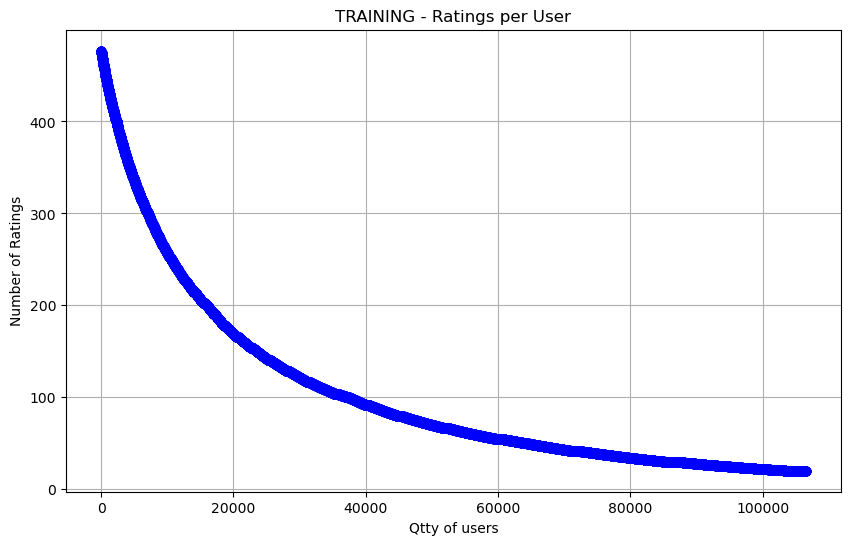

In [9]:
# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = train_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TRAINING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

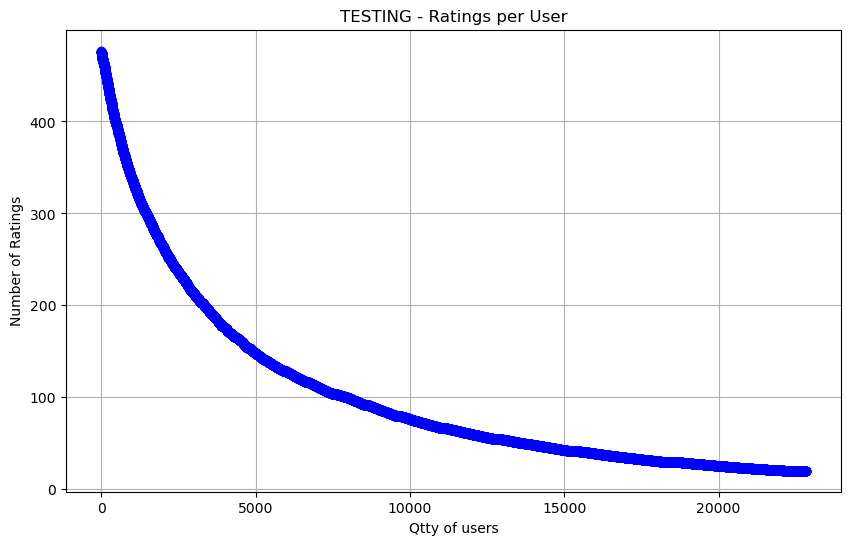

In [10]:
# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = test_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TESTING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

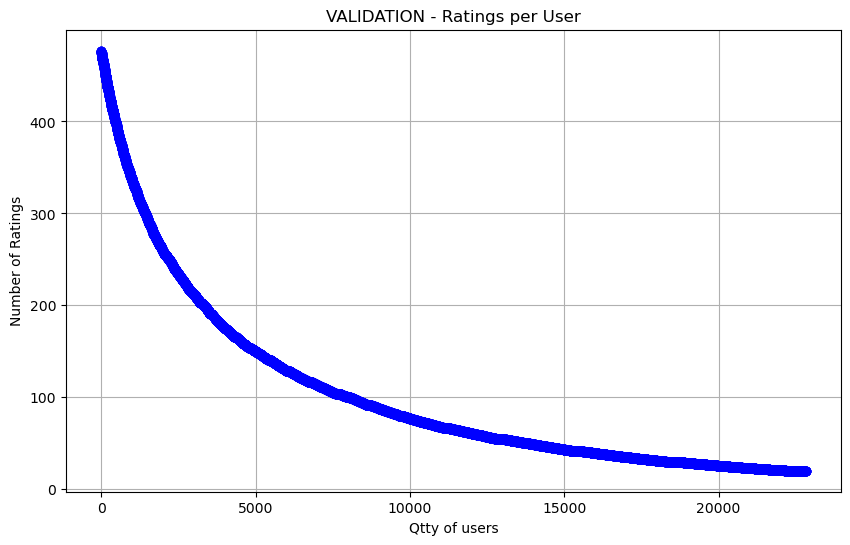

In [11]:
# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = val_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('VALIDATION - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

In [12]:
# Count the number of unique users and movies
n_users = ratings.user_id.unique().shape[0]
n_movies = movies.movie_id.unique().shape[0]
print('Number of users = ' + str(n_users) + ' | Number of movies = ' + str(n_movies))

Number of users = 152128 | Number of movies = 62423


In [13]:
Ratings = ratings.pivot(index = 'user_id', columns ='movie_id', values = 'rating').fillna(0)
Ratings.head()

/tmp/ipykernel_675322/106677598.py:1: PerformanceWarning: The following operation may generate 5290403328 cells in the resulting pandas object.
  Ratings = ratings.pivot(index = 'user_id', columns ='movie_id', values = 'rating').fillna(0)


movie_id,1,2,3,4,5,6,7,8,9,10,...,209135,209137,209139,209141,209143,209145,209147,209157,209169,209171
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# R = Ratings.as_matrix()
## 'DataFrame' object has no attribute 'as_matrix'
## Deprecated since version 0.23.0: Use DataFrame.values() instead.
### Warning: We recommend using DataFrame.to_numpy() instead. 
R = Ratings.to_numpy()

user_ratings_mean = np.mean(R, axis = 1)
Ratings_demeaned = R - user_ratings_mean.reshape(-1, 1)

In [15]:
sparsity = round(1.0 - len(ratings) / float(n_users * n_movies), 3)
print('The sparsity level of MovieLens25M dataset is ' +  str(sparsity * 100) + '%')

The sparsity level of MovieLens25M dataset is 99.8%


In [16]:
from scipy.sparse.linalg import svds
U, sigma, Vt = svds(Ratings_demeaned, k = 50)

In [17]:
sigma = np.diag(sigma)

In [18]:
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

In [19]:
preds = pd.DataFrame(all_user_predicted_ratings, columns = Ratings.columns)
preds.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,209135,209137,209139,209141,209143,209145,209147,209157,209169,209171
0,0.642472,-0.183655,-0.080504,0.028228,-0.016665,-0.206208,0.015539,0.001181,-0.008659,0.116601,...,0.001466,0.001456,0.001466,0.001466,0.001466,0.001466,0.001466,0.001468,0.001488,0.001488
1,5.389420,0.396165,-0.030605,0.031814,-0.103618,0.355844,0.245466,0.049582,-0.078638,0.662143,...,0.003111,0.003099,0.003111,0.003111,0.003111,0.003111,0.003111,0.003067,0.003046,0.003047
2,2.961522,0.223623,0.076361,0.033123,0.113782,0.068001,0.157027,0.015896,-0.009421,0.453488,...,0.000706,0.000686,0.000706,0.000706,0.000706,0.000706,0.000706,0.000659,0.000653,0.000653
3,3.805843,0.796735,1.404973,0.171705,1.230159,1.640218,1.108230,0.114024,0.522086,1.018060,...,-0.000038,-0.000041,-0.000038,-0.000038,-0.000038,-0.000038,-0.000038,0.000003,0.000049,0.000049
4,-0.256625,0.174575,0.089842,0.010745,0.107611,-0.173060,0.004826,0.036271,0.039265,-0.211616,...,0.000306,0.000294,0.000306,0.000306,0.000306,0.000306,0.000306,0.000326,0.000371,0.000371


In [20]:
def recommend_movies(predictions, userID, movies, original_ratings, num_recommendations):
    
    # Get and sort the user's predictions
    user_row_number = userID - 1 # User ID starts at 1, not 0
    sorted_user_predictions = preds.iloc[user_row_number].sort_values(ascending=False) # User ID starts at 1
    
    # Get the user's data and merge in the movie information.
    user_data = original_ratings[original_ratings.user_id == (userID)]
    user_full = (user_data.merge(movies, how = 'left', left_on = 'movie_id', right_on = 'movie_id').
                     sort_values(['rating'], ascending=False)
                 )

    print('User {0} has already rated {1} movies.'.format(userID, user_full.shape[0]))
    print('Recommending highest {0} predicted ratings movies not already rated.'.format(num_recommendations))
    
    # Recommend the highest predicted rating movies that the user hasn't seen yet.
    recommendations = (movies[~movies['movie_id'].isin(user_full['movie_id'])].
         merge(pd.DataFrame(sorted_user_predictions).reset_index(), how = 'left',
               left_on = 'movie_id',
               right_on = 'movie_id').
         rename(columns = {user_row_number: 'Predictions'}).
         sort_values('Predictions', ascending = False).
                       iloc[:num_recommendations, :-1]
                      )

    return user_full, recommendations

In [21]:
already_rated, predictions = recommend_movies(preds, 1310, movies, ratings, 20)

User 1310 has already rated 21 movies.
Recommending highest 20 predicted ratings movies not already rated.


In [22]:
# Top 20 movies that User 1310 has rated 
already_rated.head(20)

,user_id,movie_id,rating,timestamp,title,genres
20,1310,1721,5.0,884629656,Titanic (1997),Drama|Romance
15,1310,1639,5.0,884630325,Chasing Amy (1997),Comedy|Drama|Romance
3,1310,1414,4.0,884630054,Mother (1996),Comedy
2,1310,1407,4.0,884629812,Scream (1996),Comedy|Horror|Mystery|Thriller
0,1310,1057,4.0,884630512,Everyone Says I Love You (1996),Comedy|Musical|Romance
14,1310,1629,4.0,884629982,"MatchMaker, The (1997)",Comedy|Romance
16,1310,1641,4.0,884629656,"Full Monty, The (1997)",Comedy|Drama
12,1310,1608,4.0,884630325,Air Force One (1997),Action|Thriller
10,1310,1515,4.0,884630718,Volcano (1997),Action|Drama|Thriller
18,1310,1673,4.0,884630130,Boogie Nights (1997),Drama


In [23]:
# Top 20 movies that User 1310 hopefully will enjoy
predictions

,movie_id,title,genres
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War
581,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
372,377,Speed (1994),Action|Romance|Thriller
452,457,"Fugitive, The (1993)",Thriller
375,380,True Lies (1994),Action|Adventure|Comedy|Romance|Thriller
362,367,"Mask, The (1994)",Action|Comedy|Crime|Fantasy
163,165,Die Hard: With a Vengeance (1995),Action|Crime|Thriller
339,344,Ace Ventura: Pet Detective (1994),Comedy


----

In [24]:
# Import libraries from Surprise package
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

# Load Reader library
reader = Reader()

# Load ratings dataset with Dataset library
print(f"Training set size: {len(train_ratings)}")
print(f"Testing set size: {len(test_ratings)}")
print(f"Validation set size: {len(val_ratings)}")
data = Dataset.load_from_df(train_ratings[['user_id', 'movie_id', 'rating']], reader)
test = Dataset.load_from_df(test_ratings[['user_id', 'movie_id', 'rating']], reader=data.reader)
val = Dataset.load_from_df(val_ratings[['user_id', 'movie_id', 'rating']], reader=data.reader)

Training set size: 11013518
Testing set size: 2338573
Validation set size: 2346029


In [25]:
# when using cross-val, I'll merge data and test
combined_ratings = pd.concat([train_ratings, test_ratings])
# Load the combined DataFrame into a Dataset
data_cross_val = Dataset.load_from_df(combined_ratings[['user_id', 'movie_id', 'rating']], reader)

# Split the dataset for 5-fold evaluation
n_folds=5
model = SVD()
cross_validate(model, data_cross_val, measures=['RMSE', 'MAE'], cv=n_folds, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8163  0.8170  0.8169  0.8157  0.8159  0.8164  0.0005  
MAE (testset)     0.6177  0.6182  0.6182  0.6173  0.6174  0.6178  0.0004  
Fit time          579.52  586.69  583.14  577.99  587.57  582.98  3.79    
Test time         130.00  116.31  114.26  128.17  115.05  120.76  6.86    


{'test_rmse': array([0.81626936, 0.8170042 , 0.81694357, 0.8157108 , 0.81590496]),
 'test_mae': array([0.6177005 , 0.61819716, 0.61820964, 0.61726341, 0.61739044]),
 'fit_time': (579.5164995193481,
  586.690052986145,
  583.1369330883026,
  577.9868927001953,
  587.568704366684),
 'test_time': (129.99745082855225,
  116.3094482421875,
  114.26070046424866,
  128.17251539230347,
  115.04692649841309)}

In [26]:
trainset = data.build_full_trainset()

# Train the model on the full trainset
model.fit(trainset)

In [27]:
# Now you can use the trained model to make predictions

# Picking a random user in the val set
val_users=val_ratings['user_id'].unique()

np.random.seed(SEED)

val_user_id = np.random.choice(val_users)
# picking the unique movie_ids that 'val_user_id' has already rated
watched_list = ratings[ratings['user_id'] == val_user_id]['movie_id'].unique()

# Example: predict the rating for user 196 and item 302
val_movie_id = np.random.choice(watched_list)
display(ratings[(ratings['movie_id'] == val_movie_id) & (ratings['user_id'] == val_user_id)])

prediction = model.predict(val_user_id, val_movie_id)

print("Predicted rating:", prediction.est)

,user_id,movie_id,rating,timestamp
17382926,112604,1527,3.0,967467072


Predicted rating: 3.772334554941029


In [28]:
watched_list

array([  21,   44,   60,   70,  111,  145,  160,  165,  173,  208,  260,
        288,  292,  296,  316,  318,  329,  349,  353,  377,  379,  380,
        423,  434,  457,  474,  480,  485,  493,  527,  541,  555,  589,
        590,  593,  608,  648,  733,  736,  748,  780,  786,  858,  919,
       1036, 1037, 1061, 1073, 1089, 1101, 1136, 1179, 1193, 1196, 1198,
       1200, 1201, 1210, 1213, 1214, 1220, 1222, 1228, 1240, 1247, 1250,
       1258, 1259, 1266, 1270, 1275, 1276, 1287, 1291, 1307, 1356, 1370,
       1372, 1373, 1374, 1375, 1376, 1378, 1387, 1388, 1389, 1393, 1431,
       1466, 1479, 1499, 1518, 1527, 1544, 1552, 1573, 1580, 1587, 1589,
       1590, 1597, 1610, 1617, 1645, 1676, 1687, 1704, 1729, 1752, 1754,
       1792, 1831, 1876, 1894, 1917, 1950, 1954, 1961, 1968, 2000, 2001,
       2013, 2019, 2028, 2058, 2071, 2115, 2153, 2167, 2194, 2260, 2268,
       2322, 2324, 2334, 2353, 2366, 2367, 2376, 2393, 2402, 2403, 2405,
       2406, 2409, 2410, 2411, 2412, 2457, 2470, 24

In [29]:
prediction = model.predict(val_user_id, 6975)

print("Predicted rating:", prediction.est)

display(ratings[(ratings['movie_id'] == 6975) & (ratings['user_id'] == val_user_id)])


Predicted rating: 3.720743741536204


,user_id,movie_id,rating,timestamp


In [30]:
# Prepare to calculate RMSE on validation set
val_user_ids = val_ratings['user_id'].values
val_movie_ids = val_ratings['movie_id'].values
val_true_ratings = val_ratings['rating'].values

predictions = []

# Predict ratings for the validation set
for user_id, movie_id, true_rating in zip(val_user_ids, val_movie_ids, val_true_ratings):
    prediction = model.predict(user_id, movie_id, true_rating)
    predictions.append(prediction)

In [31]:
from surprise import accuracy

# Calculate RMSE for the validation set
rmse = accuracy.rmse(predictions, verbose=True)

RMSE: 0.9702


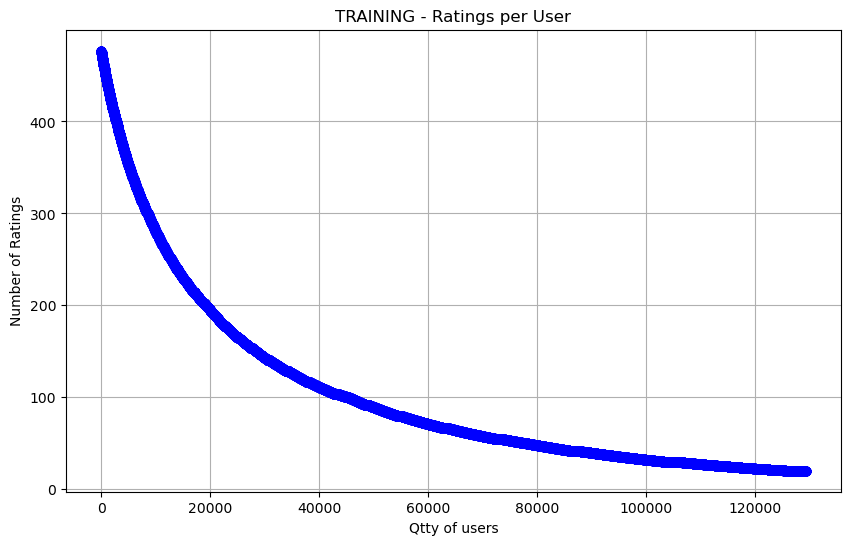

In [33]:
# combined_ratings

# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = combined_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TRAINING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

In [ ]:
# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = combined_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TRAINING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()